**In this document I will code to understand how the process of HRP works using a certain universe of simulated assets.**

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

# Universe composed of 5 assets and 6 days of returns
returns = np.array([
 [0.01, 0.02, -0.01, 0.03, 0.01, -0.02],
 [0.01, 0.02, -0.01, 0.02, 0.01, -0.01],
 [-0.02, -0.01, 0.03, -0.01, -0.02, 0.01],
 [0.00, 0.01, 0.00, 0.01, 0.00, 0.01],
 [0.01, 0.03, -0.02, 0.04, 0.01, -0.03] 
])

**Step 1: Compute the correlation of each asset**

In [17]:
corr_matrix = np.corrcoef(returns)

**Step 2: Compute the similarity of each pair of assets**. We can do  this by using the formula: $$d_{i,j} = \sqrt{0.5 \cdot (1 - p_{i,j})}$$

In [18]:
def direct_distance (corr_matrix):
    return np.sqrt(0.5 * (1 - corr_matrix))

In [19]:
dd_matrix = direct_distance(corr_matrix=corr_matrix) # Direct Distance Matrix

# We can verify if the diagonal is just composed of 0's
np.allclose(np.diag(dd_matrix),0)

True

**Step 3: Compute the euclidean distance of each asset**. We can do this by using the formula: 

$$d_{i,j} = \sqrt{\sum_{n=1}^{N}(d_{n,i} - d_{n,j})^{2}}$$

Or we can use the scipy function pdist so we don't use loops

In [20]:
def structural_distance(dd_matrix):
    return pdist(dd_matrix,metric='euclidean')

In [21]:
sd_matrix = structural_distance(dd_matrix) # Structural Distance Matrix
sd_matrix

array([0.18524235, 1.77257024, 1.18109247, 0.07599887, 1.76674344,
       1.1455134 , 0.15685577, 1.13925788, 1.78790303, 1.17711333])

**Step 4: Compute the linkage matrix:**

In [22]:
def linkage_matrix(sd_matrix):
    return linkage(sd_matrix, method='ward')

In [23]:
z = linkage_matrix(sd_matrix=sd_matrix)

In [24]:
pd.DataFrame(z)

,0,1,2,3
0,0.0,4.0,0.075999,2.0
1,1.0,5.0,0.193271,3.0
2,2.0,3.0,1.139258,2.0
3,6.0,7.0,2.150606,5.0


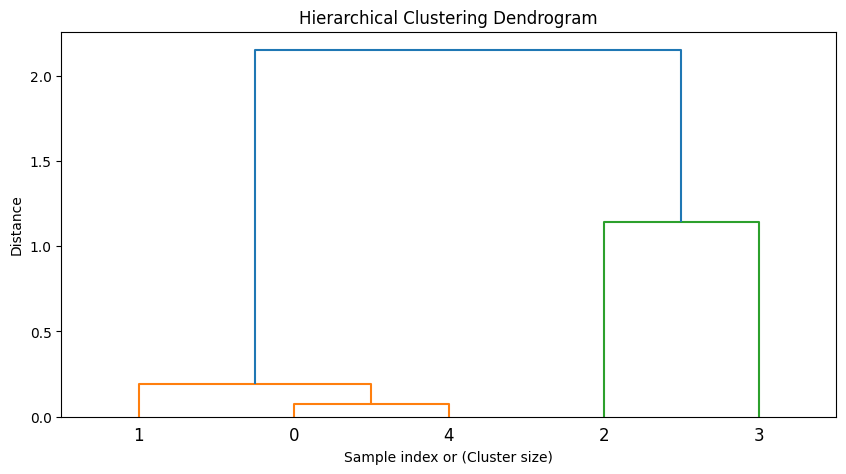

In [25]:
plt.figure(figsize=(10, 5))
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index or (Cluster size)")
plt.ylabel("Distance")

dendrogram(z)

plt.show()

**Step 5: Quasi-Diagonalization: We reorder the correlation matrix so that the largest correlations lie around the diagonal. This can be done by using matrix seriation**

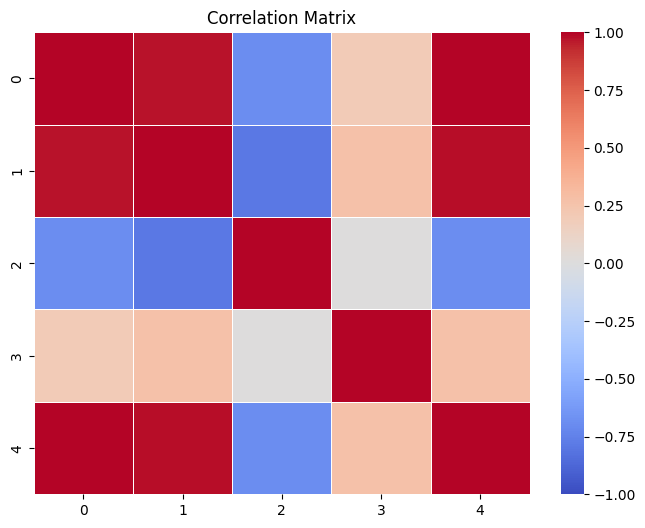

In [26]:
# First, we visualize our correlation matrix as it is before reordering it
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=False,       # Show numerical values
            cmap='coolwarm',  # Color scheme
            fmt=".2f",        # 2 decimal places
            vmin=-1, vmax=1,  # Scale range
            linewidths=0.5)   # Add lines between cells

plt.title('Correlation Matrix')
plt.show()

## **Programming the Leaf Order function**

We know that we're working with N assets, the ID's for the assets in the linkage matrix go from 0 to N-1, the values that go from N and onwards will correspond to clusters.

With this information and knowing that it is a recursive process, I can plan out my base case and recursive case.

**Base case:** $\text{node id} < N$: If our node_id is less than our number of assets, then it means that it is an individual stock, meaning it cannot be dividided any further, so we just return the id in a list.

```Python
def leaf_order(node_id,linkage_matrix, N):
    if node_id < N:
        return [node_id]
```

**Recursive case:** $\text{node id} > N$: If our node_id is greater than our number of assets, then it means that it corresponds to a cluster, meaning we have to decompose this cluster.

- **1.** We need to find out in which row the cluster formed. We know that the ID N was created in row 0 and we know that ID N+1 was created in row 1, meaning that we just have to take away the number of assets we have from the row ID to know the row in which the cluster was formed.

```Python
    else:
        row = node_id - N
```

- **2.** Next, we need to extract the row id from the left branch and the row id for the right branch, this will help us when we call the function again to decompose the cluster if the branch also corresponds to a cluster and return the id when it corresponds to an indivual asset.

```Python
        right_brach_id = int(linkage_matrix[row,0])
        lef_branch_id = int(linkage_matrix[row,1])
```

- **3.** Finally, we can call our function to decompose the clusters or returns the assets
```Python
        return leaf_order(right_branch_id, z, N) + leaf_order(left_branch_id, z, N)

In [27]:
def leaf_order(node_id, linkage_matrix, N):
    if node_id < N:
        return [node_id]
    else:
        row = node_id - N

        right_branch_id = int(linkage_matrix[row, 0])
        left_branch_id = int(linkage_matrix[row, 1])

        return leaf_order(right_branch_id, linkage_matrix, N) + leaf_order(left_branch_id, linkage_matrix, N)

In [28]:
# Now, we use our function to reorganize the correlation matrix
matrix_leaf_order = leaf_order(8,z,5)

clustered_correlations_matrix = corr_matrix[matrix_leaf_order, :][:, matrix_leaf_order]

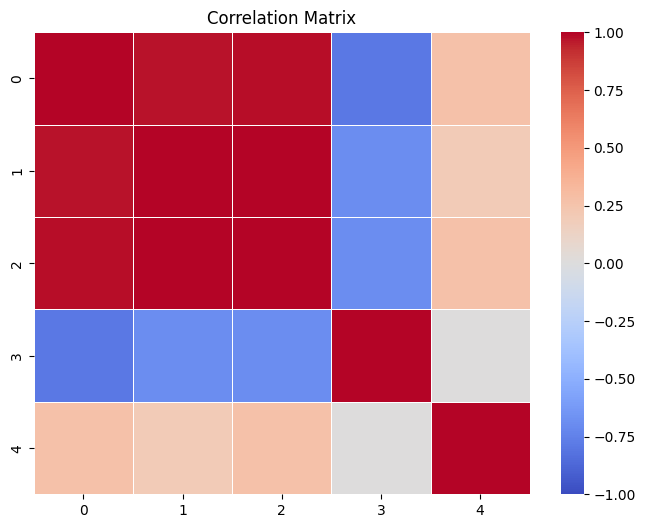

In [29]:
#  We visualize the new clustered correlations matrix

plt.figure(figsize=(8, 6))
sns.heatmap(clustered_correlations_matrix,
            annot=False,
            cmap='coolwarm',
            fmt=".2f",
            vmin=-1, vmax=1,
            linewidths=0.5)
            
plt.title('Correlation Matrix')
plt.show() 

**Step 6: Recursive Bisection**

**6.1:** We initialize the global weight of all assets to 1, which represents our whole capital. As we go down the tree, we will multiply this allocation by a split factor ($\alpha$) to reduce it until we reach the final optimal weight for each asset.

$$w_n = 1$$

**6.2:** We will make the bisection, meaning that we will cut our leaf order list in half, thus becoming our two clusters. E.g. [1, 0, 4, 2, 3] / 2 = [1, 0] , [4, 2 ,3]

**6.3:** Now, we calculate temporary internal weights ($w_{in}$) for the assets inside each cluster, ignoring the rest of the portfolio. We do this using the inverse-variance formula:
$$w_{i} = \frac{1/\sigma_{i}^{2}}{\sum(1/\sigma_{j}^{2})}$$

**6.4:** Next, we compute the aggregate variance of the entire cluster ($\tilde{V}$). We do this by multiplying the temporary weights computed in step 6.2.1 by the covariance matrix of that specific cluster ($\Sigma$): $$\tilde{V}_L = w_{in}^T \Sigma_L w_{in}$$

**6.5:** Now that we have the aggregate risk of both the left and right clusters, we make them "compete" for the capital. We use the following formula to calculate the split factor ($\alpha$), ensuring that the branch with the most risk gets a smaller allocation:
$$\alpha_L = 1 - \frac{\tilde{V}_L}{\tilde{V}_L + \tilde{V}_R}$$
$$\alpha_R = 1 - \alpha_L$$

**6.6:** Finally, we update the global weights. We multiply the current global weight of the assets in the left branch by $\alpha_L$, and the assets in the right branch by $\alpha_R$. We repeat this entire process recursively for each sub-branch until we are left with individual assets. $$W_{Left} = W_{current} \times \alpha_L$$ $$W_{Right} = W_{current} \times \alpha_R$$

## **Programming the Recursive Bisection Function**

First, we need to understand what our function will need to access.

- **Leaf order list:** We will need our leaf order so it can access the indices of the sorted assets.
- **Weights:** The universal weights for the portfolio which will be updated through the recursion process
- **Covariance matrix:** So our function can access the covariance for each cluster that will be formed

```Python
def recursive_bisection(leaf_order_list, weights, covariance_matrix):
```

As it is a recursive process, I need to plan out for the base case and recursive case.

### **1. Base Case:**
The cluster is composed of just one stock, this cannot be divided any further, so we do not return anything when our function gets here.
```Python
    if len(leaf_order_list) == 1:
        return
```

### **2. Recursive Case:** 
Once we've confirmed that the list has more than one element, we can go on  with the first step, which is the bisection.

**2.1 Bisection**

We compute the midpoint of our list and round it in case it has an uneven number of elements. Then, we use the midpoint so we can slice our list before and after the midpoint.
```Python
    else:
        mid = (len(leaf_order_list // 2))
        left_cluster = leaf_order_list[:mid]
        right_cluster = leaf_order_list[mid:]
```

**2.2 Inverse variance**

As we've seen, for the inverse variance we need the variance of the ith asset that we'll analyze. This variance can be accesed in the diagonal of the covariance matrix

But we only want the variance for the assets inside our current cluster, so the first step is to slice the covariance matrix so we just have the rows and columns corresponding to the assets in our clusters.

We can use np.ix_ to slice our matrix in this way and obtain the diagonal from this submatrix. We do this for both the left and right cluster
```Python        
        submatrix = cov_matrix(np.ix_(cluster, cluster)) # Create the submatrix for the cluster we're in
        cluster_variances = np.diag(submatrix) # Get the diagonal for the variances
        inverse_variance = 1 / cluster_variances
        temp_weights = inverse_variance / sum(inverse_variance)
```
**2.3 Compute the aggregate variance**

We compute the aggregate variance for each cluster
```Python
        cluster_variance = temp_weights.T @ submatrix @ temp_weights 
```

**2.4 Split Factor**
```Python
        alpha_left = 1 - (left_cluster_variance / left_cluster_variance + right_cluster_variance)
        alpha_right = 1- alpha_left
```

In [48]:
def recursive_bisection(leaf_order_list, weights, covariance_matrix):
    if len(leaf_order_list) <= 1:
        return

    # 2.1 Bisection
    mid = len(leaf_order_list) // 2
    left_cluster = leaf_order_list[:mid]
    right_cluster = leaf_order_list[mid:]

    #  2.2 Inverse variance
    left_submatrix = cov_matrix[np.ix_(left_cluster, left_cluster)]
    left_cluster_variances = np.diag(left_submatrix)
    left_inv_var = 1 / left_cluster_variances
    left_temp_weights = left_inv_var / sum(left_inv_var)

    right_submatrix = cov_matrix[np.ix_(right_cluster, right_cluster)]
    right_cluster_variances = np.diag(right_submatrix)
    right_inv_var = 1 / right_cluster_variances
    right_temp_weights = right_inv_var / sum(right_inv_var)

    # 2.3 Aggregate variance
    left_cluster_variance = left_temp_weights.T @ left_submatrix @ left_temp_weights
    right_cluster_variance = right_temp_weights.T @ right_submatrix @ right_temp_weights

    # 2.4 Compute the split factor
    alpha_left = 1 - (left_cluster_variance / left_cluster_variance + right_cluster_variance)
    alpha_right = 1- alpha_left

    #2.5 Update the weights
    weights[left_cluster] *= alpha_left
    weights[right_cluster] *= alpha_right

    # 2.6 We call the function recursively on each cluster
    recursive_bisection(left_cluster, weights, covariance_matrix)
    recursive_bisection(right_cluster, weights, covariance_matrix)